# Exploratory Data Analysis (EDA) — Diabetes Risk Dataset

**Goal:** Analyze a patient health dataset to uncover patterns and trends related to diabetes risk, 
using statistical summaries and visualizations, and identify the key influencing factors.

**Dataset:** `diabetes_health_dataset.csv` — 773 patient records with 8 clinical features 
(Pregnancies, Glucose, Blood Pressure, Skin Thickness, Insulin, BMI, Diabetes Pedigree Function, Age) 
and a binary `Outcome` (1 = diabetic, 0 = non-diabetic).

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('../data/diabetes_health_dataset.csv')
print('Shape:', df.shape)
df.head()

Shape: (773, 9)


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  DiabetesPedigreeFunction  Age  Outcome
0            4     92.0           61.0           27.0      0.0  16.3                     0.504   26        0
1            2    122.0           78.0           29.0     50.0  22.2                     0.172   67        0
2            2    149.0          103.0           15.0    120.0  32.0                     0.383   60        1
3            2    102.0           82.0            0.0     59.0  22.6                     0.080   47        0
4            2    110.0           77.0           16.0     57.0  25.2                     0.080   46        0


## 2. Initial Inspection

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 773 entries, 0 to 772
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               773 non-null    int64  
 1   Glucose                   766 non-null    float64
 2   BloodPressure             773 non-null    float64
 3   SkinThickness             773 non-null    float64
 4   Insulin                   773 non-null    float64
 5   BMI                       762 non-null    float64
 6   DiabetesPedigreeFunction  773 non-null    float64
 7   Age                       773 non-null    int64  
 8   Outcome                   773 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.5 KB


In [3]:
df.describe().T

                          count        mean        std    min      25%      50%      75%     max
Pregnancies               773.0    2.216041   1.482594   0.00    1.000    2.000    3.000    8.00
Glucose                   766.0  116.181462  20.968129  60.00  103.000  116.000  129.000  178.00
BloodPressure             773.0   78.390686  16.382096   0.00   71.000   79.000   88.000  118.00
SkinThickness             773.0   19.041397   9.848639   0.00   13.000   20.000   26.000   45.00
Insulin                   773.0   77.571798  59.912320   0.00   27.000   73.000  119.000  283.00
BMI                       762.0   24.249213   5.702433   0.00   20.825   24.500   28.000   41.60
DiabetesPedigreeFunction  773.0    0.391250   0.264212   0.08    0.186    0.329    0.533    1.67
Age                       773.0   50.970246  17.223249  21.00   36.000   51.000   66.000   80.00
Outcome                   773.0    0.060802   0.239122   0.00    0.000    0.000    0.000    1.00


## 3. Data Cleaning

Two issues stand out from the initial inspection:

1. **Duplicate rows** — a few records are exact duplicates (likely a data pipeline artifact).
2. **Biologically implausible zeros** — `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and 
   `BMI` cannot realistically be `0` for a living patient; these are almost certainly missing values 
   encoded as zero.

**Approach:** drop duplicates, convert the implausible zeros to `NaN`, then impute using the **median 
within each Outcome group** (diabetic vs. non-diabetic) rather than a single global median — this keeps 
the distributional difference between the two groups intact instead of blurring it.

In [4]:
before = len(df)
df = df.drop_duplicates()
print(f'Removed {before - len(df)} duplicate rows')

zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('Implausible zero counts:')
print((df[zero_as_missing] == 0).sum())

for col in zero_as_missing:
    df[col] = df[col].replace(0, np.nan)

print('\nMissing values after converting zeros to NaN:')
print(df.isna().sum())

Removed 5 duplicate rows
Implausible zero counts:
Glucose            0
BloodPressure     15
SkinThickness     69
Insulin          138
BMI                6

Missing values after converting zeros to NaN:
Glucose            7
BloodPressure     15
SkinThickness     69
Insulin          138
BMI               17


In [5]:
for col in zero_as_missing + ['Glucose', 'BMI']:
    df[col] = df.groupby('Outcome')[col].transform(lambda s: s.fillna(s.median()))

df['Outcome_Label'] = df['Outcome'].map({0: 'No Diabetes', 1: 'Diabetes'})
print('Missing values remaining:', df.isna().sum().sum())
df.describe().T

Missing values remaining: 0


                          count        mean        std    min        25%       50%        75%     max
Pregnancies               768.0    2.212240   1.481923   0.00    1.00000    2.0000    3.00000    8.00
Glucose                   768.0  116.175781  20.854974  60.00  103.00000  116.0000  129.00000  178.00
BloodPressure             768.0   79.932292  12.097091  40.00   72.00000   79.5000   88.00000  118.00
SkinThickness             768.0   20.846354   7.859122   1.00   16.00000   20.0000   26.00000   45.00
Insulin                   768.0   92.977865  47.244442   1.00   63.00000   86.0000  119.00000  283.00
BMI                       768.0   24.475781   5.181067  15.00   20.97500   24.4000   28.00000   41.60
DiabetesPedigreeFunction  768.0    0.390427   0.263366   0.08    0.18575    0.3285    0.53225    1.67
Age                       768.0   50.968750  17.190749  21.00   36.00000   51.0000   66.00000   80.00
Outcome                   768.0    0.059896   0.237448   0.00    0.00000    0.0000

## 4. Class Balance

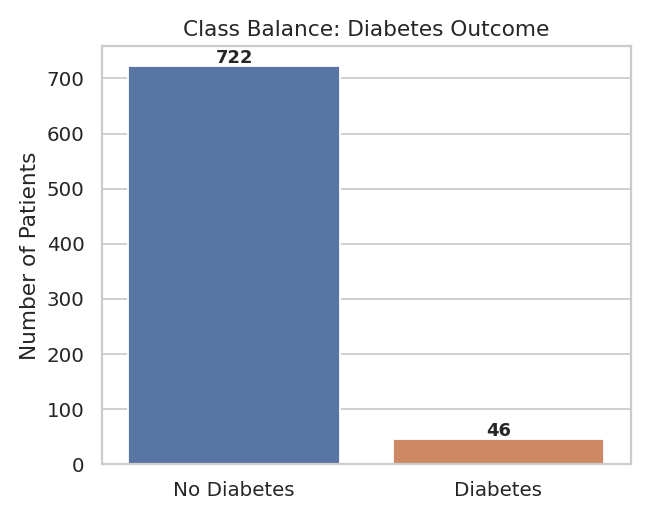

In [6]:
counts = df['Outcome_Label'].value_counts()
fig, ax = plt.subplots(figsize=(5,4))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette={'No Diabetes':'#4C72B0','Diabetes':'#DD8452'}, legend=False, ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v+5, str(v), ha='center', fontweight='bold')
ax.set_title('Class Balance: Diabetes Outcome')
plt.tight_layout(); plt.show()

The dataset is moderately imbalanced (fewer diabetic than non-diabetic records), which is typical for 
real-world screening data and is worth noting for any downstream modeling.

## 5. Feature Distributions

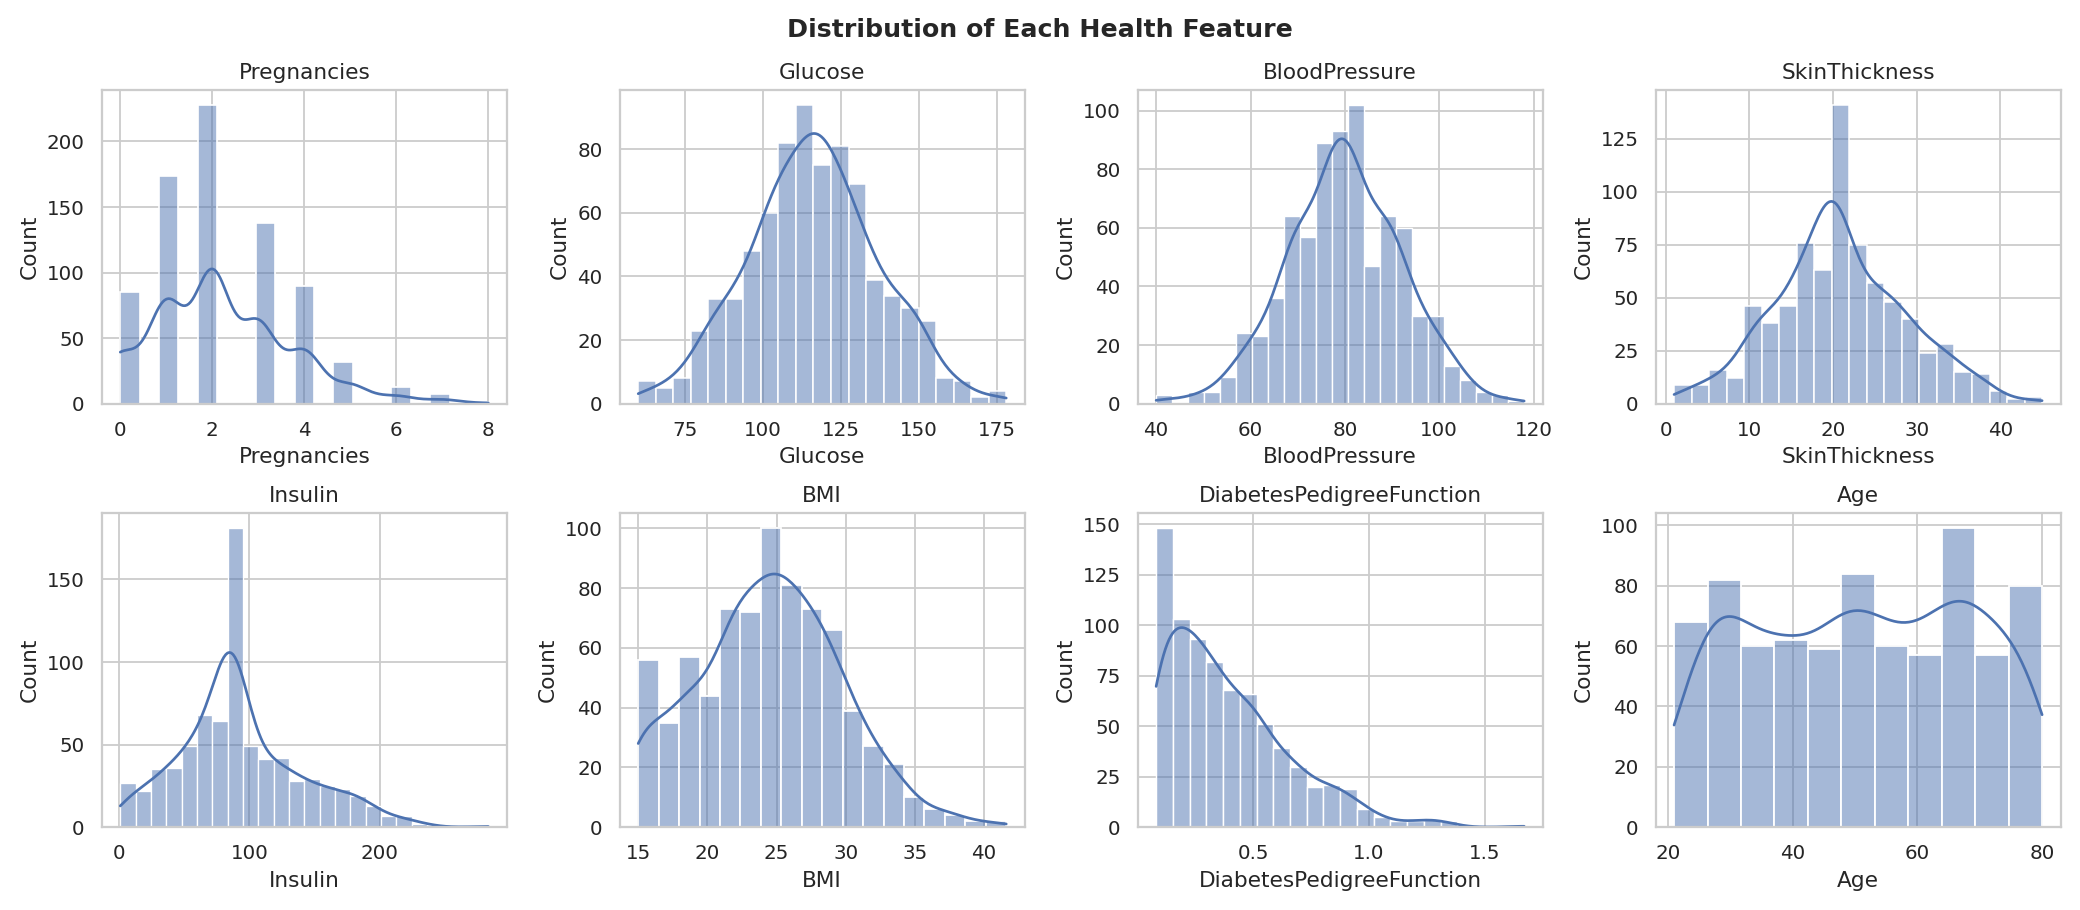

In [7]:
num_cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
fig, axes = plt.subplots(2, 4, figsize=(16,7))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(col)
plt.tight_layout(); plt.show()

## 6. Outlier Check — Feature Spread by Outcome

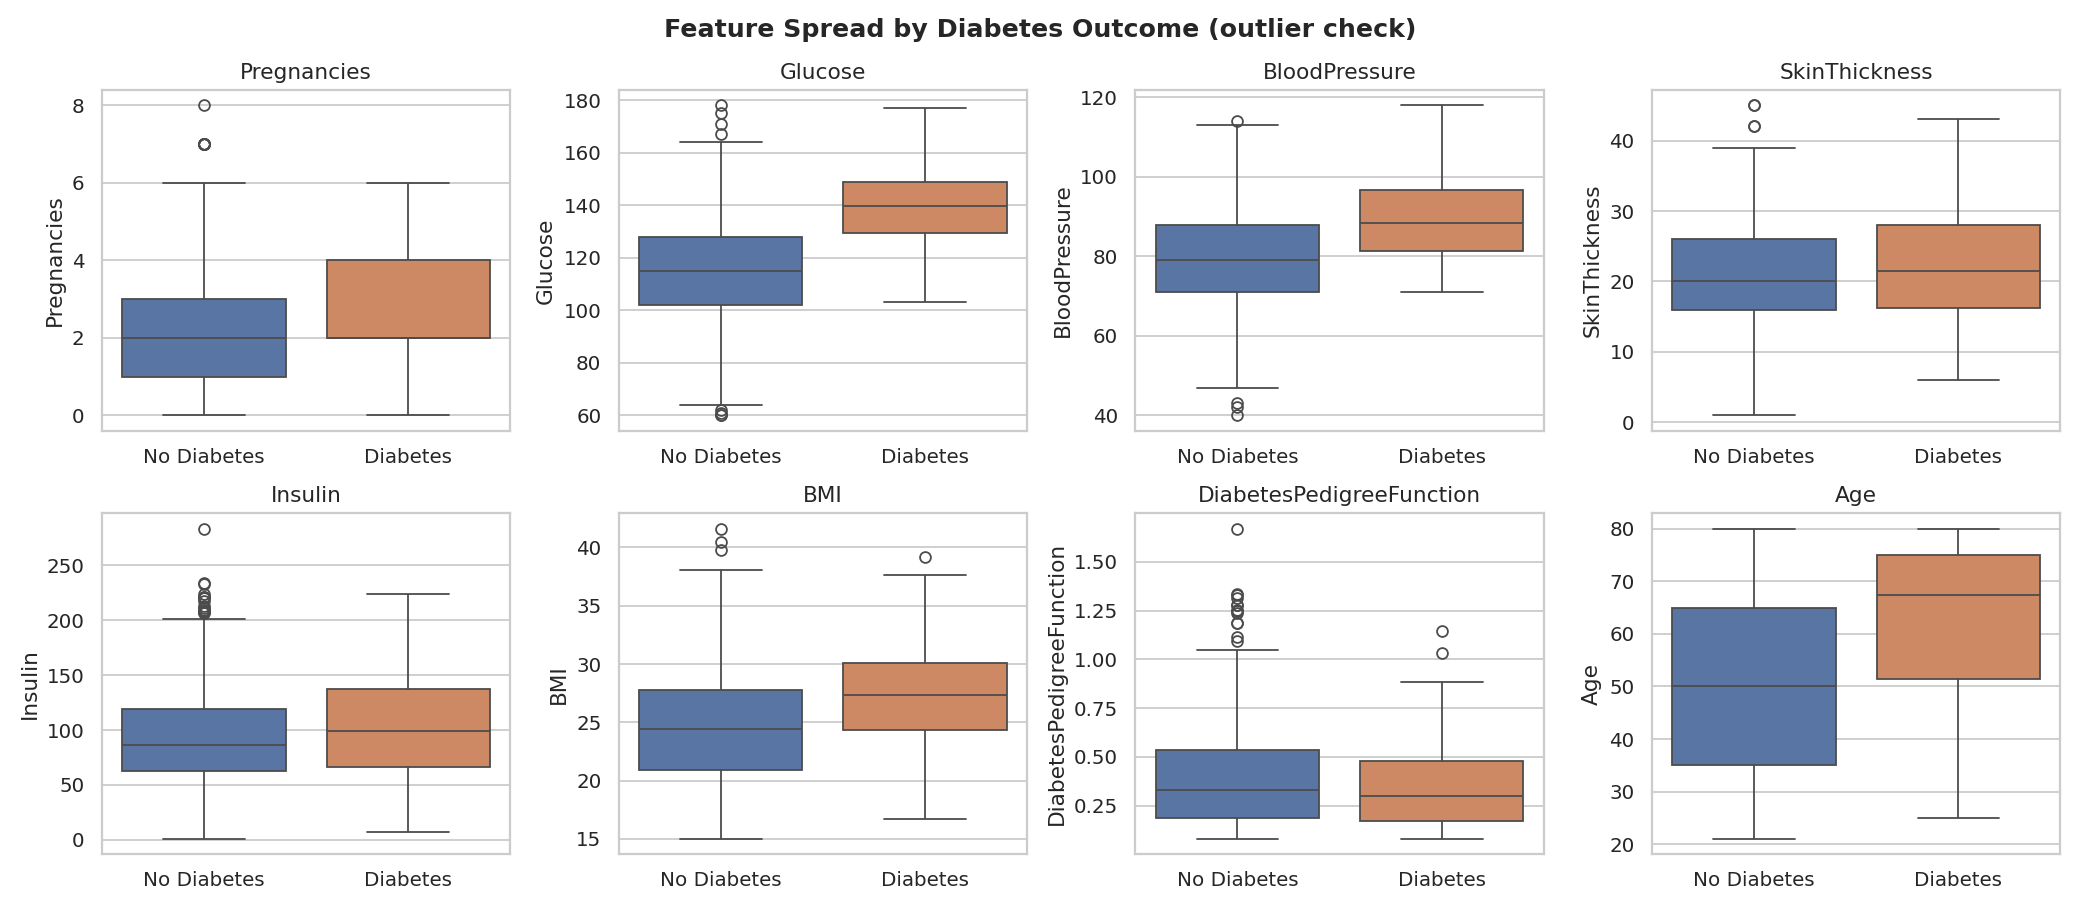

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16,7))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(data=df, x='Outcome_Label', y=col, hue='Outcome_Label', palette={'No Diabetes':'#4C72B0','Diabetes':'#DD8452'}, legend=False, ax=ax)
    ax.set_title(col); ax.set_xlabel('')
plt.tight_layout(); plt.show()

## 7. Correlation Analysis

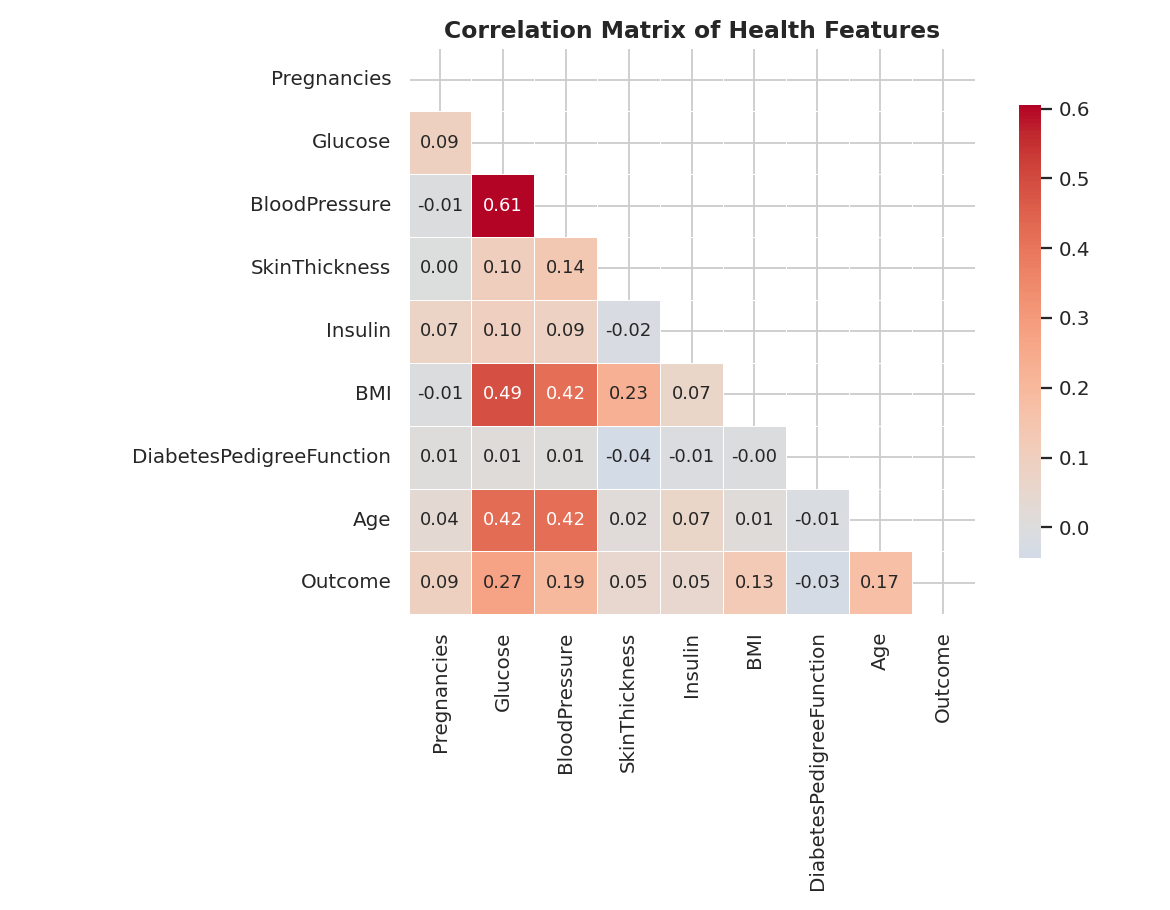

In [9]:
corr = df.drop(columns=['Outcome_Label']).corr()
fig, ax = plt.subplots(figsize=(9,7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout(); plt.show()

In [10]:
outcome_corr = corr['Outcome'].drop('Outcome').sort_values(key=abs, ascending=False)
outcome_corr

Glucose                     0.271687
BloodPressure               0.194773
Age                         0.173257
BMI                         0.128778
Pregnancies                 0.093508
SkinThickness               0.052446
Insulin                     0.051488
DiabetesPedigreeFunction   -0.031516


**Key influencing factors** (strongest correlation with diabetes outcome, in order): 
`Glucose`, `BloodPressure`, `Age`, and `BMI`. This matches clinical intuition — elevated blood sugar, 
blood pressure, body mass, and older age are all established diabetes risk indicators.

## 8. Relationship Between Top Risk Factors

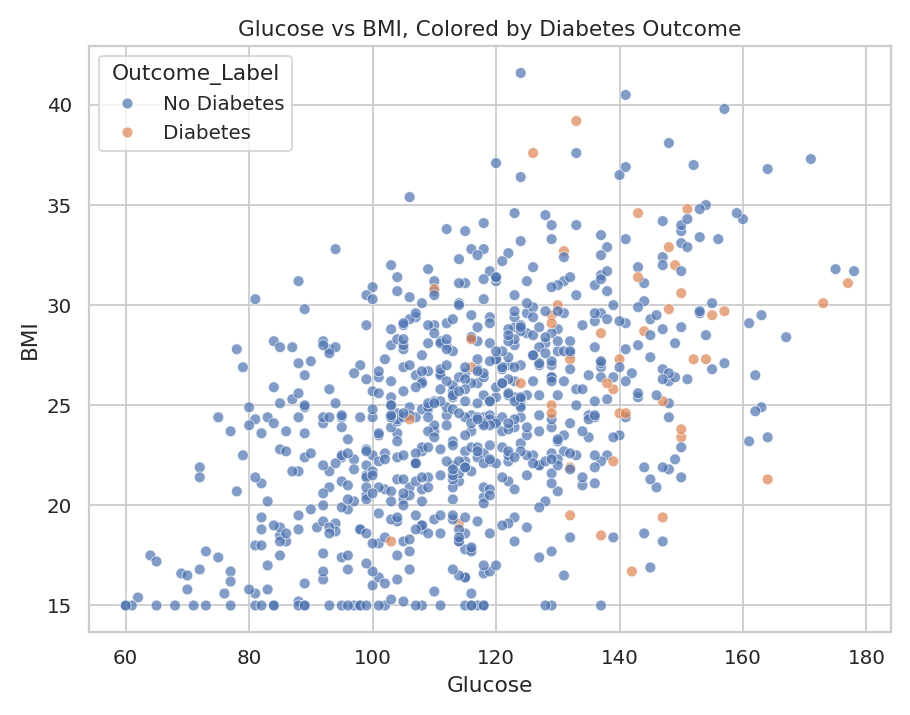

In [11]:
fig, ax = plt.subplots(figsize=(7,5.5))
sns.scatterplot(data=df, x='Glucose', y='BMI', hue='Outcome_Label', palette={'No Diabetes':'#4C72B0','Diabetes':'#DD8452'}, alpha=0.7, ax=ax)
ax.set_title('Glucose vs BMI, Colored by Diabetes Outcome')
plt.tight_layout(); plt.show()

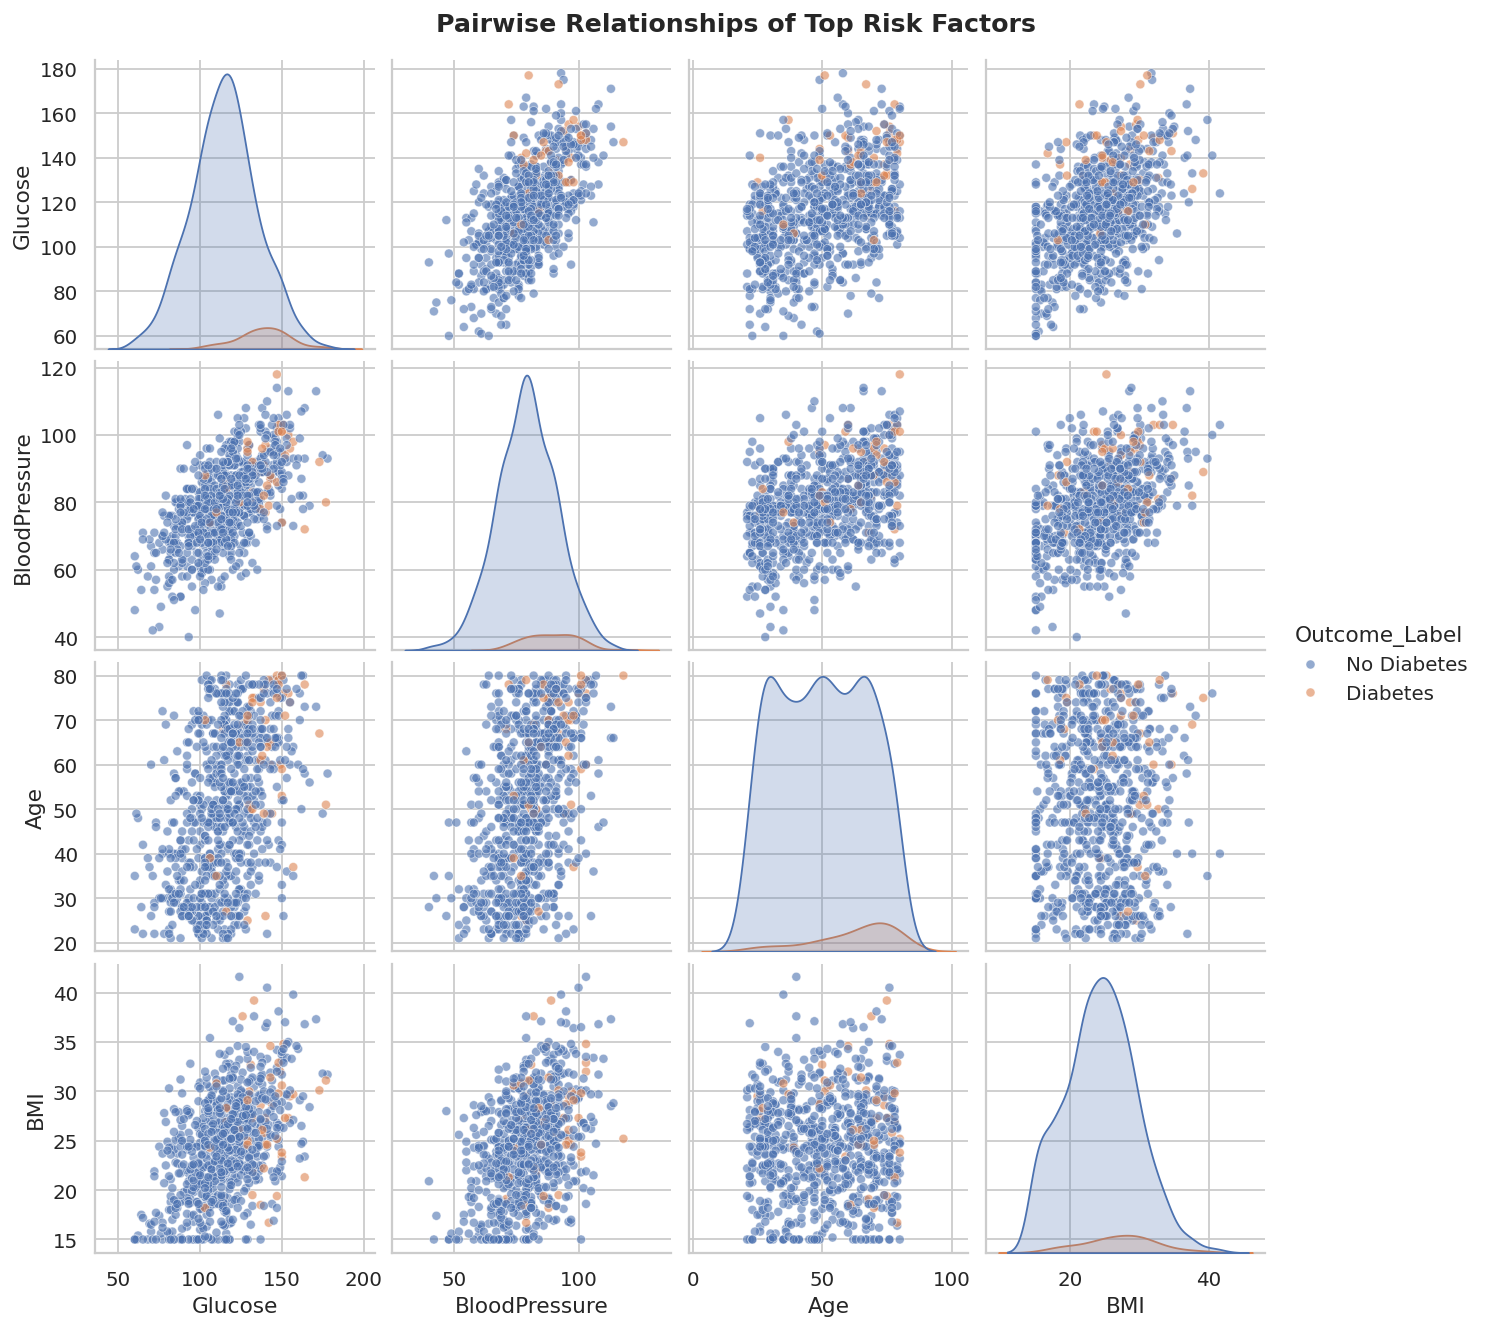

In [12]:
top_feats = list(outcome_corr.index[:4]) + ['Outcome_Label']
sns.pairplot(df[top_feats], hue='Outcome_Label', palette={'No Diabetes':'#4C72B0','Diabetes':'#DD8452'}, diag_kind='kde', plot_kws={'alpha':0.6,'s':25})
plt.show()

## 9. Summary of Insights

- **Data quality:** duplicate rows and implausible zero-values in several clinical columns needed to be 
  cleaned before analysis; both were corrected using group-aware imputation.
- **Class balance:** diabetic cases are the minority class — relevant for any future predictive modeling 
  (accuracy alone would be a misleading metric).
- **Strongest risk indicators:** `Glucose` has the strongest individual correlation with diabetes outcome, 
  followed by `BloodPressure`, `Age`, and `BMI`.
- **Compounding effect:** patients with *both* high glucose and high BMI show a visibly higher concentration 
  of diabetic outcomes in the scatter plot — the risk factors appear to compound rather than act independently.
- **Weak/no signal:** `DiabetesPedigreeFunction`, `SkinThickness`, and `Insulin` show comparatively weak 
  linear correlation with the outcome in this dataset, though they may still interact with other variables.

These findings would support a triage-style screening approach prioritizing glucose, blood pressure, age, 
and BMI as the most informative early indicators.